# Forecasting Electricity Demand in Georgia Using Machine Learning (Time Series Forecasting)

### Can historical electricity demand combined with historical weather observations accurately predict electricity demand for the next immediate hour?

In [1]:
import pandas as pd

demand = pd.read_csv("data/soco_hourly_demand_2years.csv")
weather = pd.read_csv("data/atlanta_hourly_weather_2years.csv")

print(f"Demand rows loaded:  {len(demand)}")
print(f"Weather rows loaded: {len(weather)}")

Demand rows loaded:  17520
Weather rows loaded: 17520


In [2]:
demand["value"] = pd.to_numeric(demand["value"], errors="coerce")

# Normalize timestamp formats: EIA = "...T00", Open-Meteo = "...T00:00"
# String-based merge would silently return 0 matches without this
demand["period"] = pd.to_datetime(demand["period"])
weather["period"] = pd.to_datetime(weather["period"])

# Rename demand's target column for clarity downstream
# EIA reports hourly demand as average power over the hour -> MW
demand = demand.rename(columns={"value": "demand_mw"})


In [3]:
demand_dupes = demand["period"].duplicated().sum()
weather_dupes = weather["period"].duplicated().sum()
print(f"Duplicate timestamps — demand: {demand_dupes}, weather: {weather_dupes}")
if demand_dupes > 0:
    demand = demand.drop_duplicates(subset="period", keep="first")
if weather_dupes > 0:
    weather = weather.drop_duplicates(subset="period", keep="first")

Duplicate timestamps — demand: 0, weather: 0


In [4]:
merged = pd.merge(
    demand[["period", "demand_mw"]],
    weather[["period", "temperature_f", "apparent_temperature_f", "dew_point_f", "relative_humidity_pct", "precipitation_in", "cloud_cover_pct", "wind_speed_mph"]],
    on="period",
    how="inner"
)

print(f"\nMerged rows: {len(merged)}")
print(f"Demand rows dropped in merge:  {len(demand) - len(merged)}")
print(f"Weather rows dropped in merge: {len(weather) - len(merged)}")


Merged rows: 17520
Demand rows dropped in merge:  0
Weather rows dropped in merge: 0


In [5]:
print("\nMissing values per column:")
print(merged.isna().sum())


Missing values per column:
period                    0
demand_mw                 0
temperature_f             0
apparent_temperature_f    0
dew_point_f               0
relative_humidity_pct     0
precipitation_in          0
cloud_cover_pct           0
wind_speed_mph            0
dtype: int64


In [6]:
merged = merged.sort_values("period").reset_index(drop=True)
expected_range = pd.date_range(start=merged["period"].min(), end=merged["period"].max(), freq="h")
missing_hours = expected_range.difference(merged["period"])
print(f"\nExpected hourly timestamps: {len(expected_range)}")
print(f"Actual rows: {len(merged)}")
print(f"Missing hours: {len(missing_hours)}")
if len(missing_hours) > 0:
    print("First few missing timestamps:", missing_hours[:5].tolist())


Expected hourly timestamps: 17520
Actual rows: 17520
Missing hours: 0


In [7]:
merged.to_csv("data/merged_full.csv", index=False)
print(f"\nSaved to data/merged_full.csv — {len(merged)} rows, {merged.shape[1]} columns")
merged.head()


Saved to data/merged_full.csv — 17520 rows, 9 columns


,period,demand_mw,temperature_f,apparent_temperature_f,dew_point_f,relative_humidity_pct,precipitation_in,cloud_cover_pct,wind_speed_mph
0,2024-05-01 00:00:00,29320,69.7,73.0,62.1,77,0.000,14,2.2
1,2024-05-01 01:00:00,28690,65.2,68.8,62.3,90,0.004,10,1.7
2,2024-05-01 02:00:00,27901,62.4,64.9,61.3,96,0.000,8,3.4
3,2024-05-01 03:00:00,25859,63.4,66.7,62.2,96,0.000,0,2.2
4,2024-05-01 04:00:00,23655,62.7,65.8,62.0,97,0.000,0,2.5


## Exploratory Data Analysis

Two diagnostic plots on the merged dataset:

1. Electricity demand over time: confirms the demand and weather series were collected and merged successfully, and reveals seasonality plus daily/weekly patterns that motivate time series forecasting.

2. Temperature vs. electricity demand: shows the relationship between a key weather predictor and the target, motivating the inclusion of weather variables in the models.

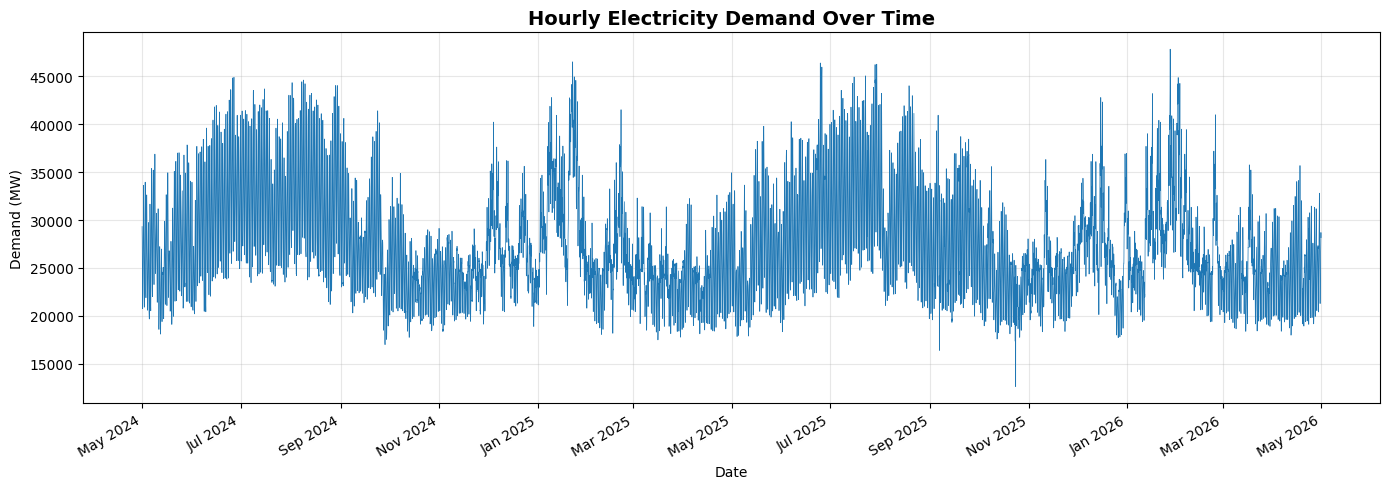

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Fall back to the saved merged dataset if the kernel was restarted
if "merged" not in globals():
    merged = pd.read_csv("data/merged_full.csv", parse_dates=["period"])

# Plot 1: Hourly electricity demand over time (line plot)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(merged["period"], merged["demand_mw"], linewidth=0.5, color="#1f77b4")

ax.set_title("Hourly Electricity Demand Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

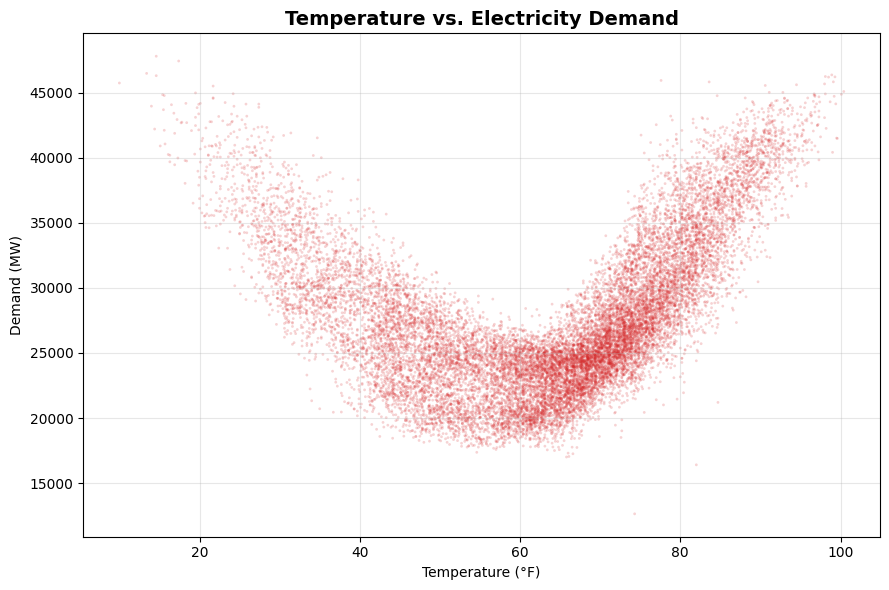

In [9]:
# Plot 2: Temperature vs. electricity demand (scatter plot)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(merged["temperature_f"], merged["demand_mw"],
           s=4, alpha=0.2, color="#d62728", edgecolors="none")

ax.set_title("Temperature vs. Electricity Demand", fontsize=14, fontweight="bold")
ax.set_xlabel("Temperature (\u00b0F)")
ax.set_ylabel("Demand (MW)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Engineering & Train/Test Split

Build time-based calendar features (`hour`, `day_of_week`, `month`) and lagged demand features (`lag_1`, `lag_24`, `lag_168`), then perform a chronological train/test split holding out the **last 2 weeks (336 hours)** for testing (no shuffling, future data must never leak into training). 

In [10]:
# Ensure chronological order before computing lags
df = merged.sort_values("period").reset_index(drop=True)

# Calendar features
df["hour"] = df["period"].dt.hour            # daily demand cycle (morning/afternoon/evening peaks)
df["day_of_week"] = df["period"].dt.dayofweek  # 0=Mon..6=Sun; weekdays vs weekends differ
df["month"] = df["period"].dt.month          # seasonal changes (summer vs winter)

# Lag features (demand shifted back in time)
df["lag_1"] = df["demand_mw"].shift(1)       # demand 1 hour ago
df["lag_24"] = df["demand_mw"].shift(24)     # same hour yesterday
df["lag_168"] = df["demand_mw"].shift(168)   # same hour one week ago (24 x 7)

# The first 168 rows have NaN lags — drop them so models see complete features
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {rows_before - len(df)} rows with incomplete lags (expected 168)")
print(f"Feature dataset: {len(df)} rows, {df.shape[1]} columns")
df.head()

Dropped 168 rows with incomplete lags (expected 168)
Feature dataset: 17352 rows, 15 columns


,period,demand_mw,temperature_f,apparent_temperature_f,dew_point_f,relative_humidity_pct,precipitation_in,cloud_cover_pct,wind_speed_mph,hour,day_of_week,month,lag_1,lag_24,lag_168
0,2024-05-08 00:00:00,33852,79.8,82.2,64.6,60,0.0,31,6.8,0,2,5,34640.0,33822.0,29320.0
1,2024-05-08 01:00:00,33152,74.3,78.4,65.8,75,0.0,98,4.1,1,2,5,33852.0,32738.0,28690.0
2,2024-05-08 02:00:00,32186,73.6,77.3,65.8,77,0.0,48,5.1,2,2,5,33152.0,31457.0,27901.0
3,2024-05-08 03:00:00,29970,73.0,76.1,65.1,76,0.0,14,5.8,3,2,5,32186.0,29058.0,25859.0
4,2024-05-08 04:00:00,27617,72.2,74.7,64.4,76,0.0,20,6.5,4,2,5,29970.0,26632.0,23655.0


In [11]:
# Chronological train/test split (last 2 weeks held out)
feature_cols = [
    # Weather features
    "temperature_f", "apparent_temperature_f", "dew_point_f",
    "relative_humidity_pct", "precipitation_in", "cloud_cover_pct", "wind_speed_mph",
    # Time features
    "hour", "day_of_week", "month",
    # Previous demand
    "lag_1", "lag_24", "lag_168",
]
target_col = "demand_mw"

TEST_HOURS = 24 * 14  # last 2 weeks held out for testing
split_idx = len(df) - TEST_HOURS

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train, y_train = train[feature_cols], train[target_col]
X_test, y_test = test[feature_cols], test[target_col]

print(f"Train: {len(X_train)} rows | {train['period'].min()} -> {train['period'].max()}")
print(f"Test:  {len(X_test)} rows | {test['period'].min()} -> {test['period'].max()}")

Train: 17016 rows | 2024-05-08 00:00:00 -> 2026-04-16 23:00:00
Test:  336 rows | 2026-04-17 00:00:00 -> 2026-04-30 23:00:00


## Baseline Models: Naive Forecast & Linear Regression

Before using the models from other tiers, the baseline models below were chosen to assess how well can you predict demand with low/almost no effort:

The naive forecast is about as simple as it gets, it just guesses that the next hour's demand will be whatever demand was one hour ago. No training, no features, nothing. It sounds too simple to be useful, but it's very effective at telling if a complicated model can't beat this, it's not worth using.

Linear regression is a small step up. It looks at all weather and calendar features (temperature, humidity, hour of day, ...) and fits a straight-line relationship between those and demand. It's still a simple model, but now it has something to work with. Both are evaluated on the same held-out two weeks as everything else, so we can see how much (if any) improvement the fancier models actually buy us.

In [12]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    """Return RMSE, MAE, and MAPE (%) for a set of predictions."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

# Model 1: Naive forecast (predict demand[t] with demand[t-1])
# lag_1 already holds the previous hour's demand, so no training is needed
naive_pred = X_test["lag_1"]
naive_rmse, naive_mae, naive_mape = evaluate(y_test, naive_pred)

print("Naive forecast (lag_1):")
print(f"  RMSE: {naive_rmse:,.1f} MW")
print(f"  MAE:  {naive_mae:,.1f} MW")
print(f"  MAPE: {naive_mape:.2f}%")

Naive forecast (lag_1):
  RMSE: 1,136.7 MW
  MAE:  885.3 MW
  MAPE: 3.57%


In [13]:
from sklearn.linear_model import LinearRegression

# Model 2: Linear regression on engineered features
# feature_cols (defined in the split cell) contains calendar, lag, and weather
# features only — demand_mw (the target) is deliberately excluded
assert target_col not in feature_cols, "Target must not be an input feature"

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_rmse, lr_mae, lr_mape = evaluate(y_test, lr_pred)

print("Linear regression:")
print(f"  RMSE: {lr_rmse:,.1f} MW")
print(f"  MAE:  {lr_mae:,.1f} MW")
print(f"  MAPE: {lr_mape:.2f}%")

Linear regression:
  RMSE: 860.2 MW
  MAE:  626.4 MW
  MAPE: 2.54%


In [14]:
# Baseline comparison table, both models evaluated on the identical test set
results = pd.DataFrame(
    {
        "Model": ["Naive (lag_1)", "Linear Regression"],
        "RMSE (MW)": [naive_rmse, lr_rmse],
        "MAE (MW)": [naive_mae, lr_mae],
        "MAPE (%)": [naive_mape, lr_mape],
    }
).round(2)

results

,Model,RMSE (MW),MAE (MW),MAPE (%)
0,Naive (lag_1),1136.68,885.33,3.57
1,Linear Regression,860.19,626.41,2.54


## Time Series Models: SARIMA & Prophet

Linear regression treats each hour as its own independent row. Models are built specifically for time series data, they take the order of time into account (that's what time series means).

**SARIMA (Seasonal ARIMA)**: This model predicts demand mostly by looking at demand's own recent past, plus it accounts for the repeating 24-hour daily cycle. SARIMA has a handful of settings that control how many past hours and past errors it factors in (written as `(p,d,q)` and a seasonal `(P,D,Q)`), and we don't know ahead of time which combination will work best, so we tried a grid of reasonable options and compared them using AIC, a standard score for comparing time series models where lower is better. Training on all two years of hourly data turned out to be too slow to be practical, so we trained on just the most recent 90 days instead. Once we picked the best settings, we tested the model the same way as everything else: predicting one hour ahead at a time, always using the real demand from the hour before, over the same two-week test period as the other models.

**Prophet**: Prophet is a forecasting tool (built by Meta) that automatically handles daily, weekly, and yearly patterns, and it can also take extra inputs, so we chose to add temperature. It has two main settings that control how flexible the model is (`changepoint_prior_scale` and `seasonality_prior_scale`), and we tried six combinations of those on a held-out week of training data to pick the best one. The one big difference from SARIMA: Prophet predicts the entire two-week test period in one shot, rather than one hour at a time, that's just how Prophet is designed to be used.

In [15]:
import sys
!{sys.executable} -m pip install statsmodels prophet --break-system-packages


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [16]:
import itertools
import time
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")  # silence convergence/frequency chatter during the grid search

SEASONAL_PERIOD = 24

# Seasonal SARIMA is computationally expensive on the full hourly training series.
# Use the most recent 90 days of training data to keep candidate model fitting
# tractable while retaining enough observations to model the 24-hour daily cycle.
SARIMA_WINDOW_HOURS = 24 * 90  # last 90 days for tuning + final SARIMA fit

# Build a continuous hourly demand series (index = period, freq = h)
y_full = df.set_index("period")["demand_mw"].asfreq("h")
y_train_ts_full = y_full.iloc[:split_idx]
y_train_ts = y_train_ts_full.iloc[-SARIMA_WINDOW_HOURS:]  # trimmed window used for SARIMA
y_test_ts = y_full.iloc[split_idx:]
print(f"SARIMA training window: {y_train_ts.index.min()} -> {y_train_ts.index.max()} ({len(y_train_ts)} hours)")

# candidate models fitted on the 90-day window minus the final week and selected using AIC
validation_hours = 24 * 7
train_inner = y_train_ts.iloc[:-validation_hours]

# Grid: (p,d,q) in {1,2}x{0,1}x{0,1}, seasonal (P,1,Q) in {0,1}x{1}x{0,1}, s=24
param_grid = list(itertools.product([1, 2], [0, 1], [0, 1]))
seasonal_grid = list(itertools.product([0, 1], [1], [0, 1]))

best_aic, best_order, best_seasonal = float("inf"), None, None
for order in param_grid:
    for seasonal in seasonal_grid:
        try:
            t0 = time.time()
            res = SARIMAX(
                train_inner,
                order=order,
                seasonal_order=(seasonal[0], seasonal[1], seasonal[2], SEASONAL_PERIOD),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            print(f"SARIMA{order}x{(*seasonal, SEASONAL_PERIOD)}: AIC = {res.aic:,.0f}  ({time.time() - t0:.0f}s)")
            if res.aic < best_aic:
                best_aic, best_order, best_seasonal = res.aic, order, seasonal
        except Exception:
            continue

print(f"\nSelected by AIC: SARIMA{best_order}x{(*best_seasonal, SEASONAL_PERIOD)} (AIC = {best_aic:,.0f})")

# Fit the selected model on the full 90-day SARIMA training window
best_res = SARIMAX(
    y_train_ts,
    order=best_order,
    seasonal_order=(best_seasonal[0], best_seasonal[1], best_seasonal[2], SEASONAL_PERIOD),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)
best_orders = (best_order, (*best_seasonal, SEASONAL_PERIOD))

SARIMA training window: 2026-01-17 00:00:00 -> 2026-04-16 23:00:00 (2160 hours)
SARIMA(1, 0, 0)x(0, 1, 0, 24): AIC = 30,986  (0s)
SARIMA(1, 0, 0)x(0, 1, 1, 24): AIC = 30,454  (1s)
SARIMA(1, 0, 0)x(1, 1, 0, 24): AIC = 30,559  (0s)
SARIMA(1, 0, 0)x(1, 1, 1, 24): AIC = 30,148  (4s)
SARIMA(1, 0, 1)x(0, 1, 0, 24): AIC = 30,426  (0s)
SARIMA(1, 0, 1)x(0, 1, 1, 24): AIC = 29,635  (3s)
SARIMA(1, 0, 1)x(1, 1, 0, 24): AIC = 29,942  (1s)
SARIMA(1, 0, 1)x(1, 1, 1, 24): AIC = 29,462  (5s)
SARIMA(1, 1, 0)x(0, 1, 0, 24): AIC = 30,072  (0s)
SARIMA(1, 1, 0)x(0, 1, 1, 24): AIC = 29,173  (2s)
SARIMA(1, 1, 0)x(1, 1, 0, 24): AIC = 29,528  (1s)
SARIMA(1, 1, 0)x(1, 1, 1, 24): AIC = 29,045  (3s)
SARIMA(1, 1, 1)x(0, 1, 0, 24): AIC = 30,039  (0s)
SARIMA(1, 1, 1)x(0, 1, 1, 24): AIC = 29,137  (3s)
SARIMA(1, 1, 1)x(1, 1, 0, 24): AIC = 29,526  (1s)
SARIMA(1, 1, 1)x(1, 1, 1, 24): AIC = 29,020  (4s)
SARIMA(2, 0, 0)x(0, 1, 0, 24): AIC = 29,998  (0s)
SARIMA(2, 0, 0)x(0, 1, 1, 24): AIC = 29,224  (3s)
SARIMA(2, 0, 0)x(1, 

In [17]:
# Rolling one-step-ahead SARIMA forecasts over the test period.
# After each test hour, the actual value is appended without re-estimating parameters,
# so each prediction conditions on actual demand observed through the previous hour.
import gc

history = best_res
predictions = []

for i, (timestamp, actual_value) in enumerate(y_test_ts.items()):
    forecast = history.forecast(steps=1).iloc[0]
    predictions.append(forecast)
    history = history.extend(y_test_ts.iloc[[i]])

arima_pred = pd.Series(predictions, index=y_test_ts.index)

arima_rmse = np.sqrt(mean_squared_error(y_test_ts, arima_pred))
arima_mae = mean_absolute_error(y_test_ts, arima_pred)
arima_mape = (np.abs((y_test_ts - arima_pred) / y_test_ts)).mean() * 100

print(f"  RMSE: {arima_rmse:,.1f} MW")
print(f"  MAE:  {arima_mae:,.1f} MW")
print(f"  MAPE: {arima_mape:.2f}%")

  RMSE: 794.6 MW
  MAE:  274.5 MW
  MAPE: 1.13%


In [18]:
import itertools
import logging

from prophet import Prophet

logging.getLogger("cmdstanpy").setLevel(logging.WARNING)  # silence per-fit Stan chatter

def make_prophet_frame(frame):
    """Convert our schema to Prophet's expected ds/y columns, keeping temperature as a regressor."""
    return frame[["period", "demand_mw", "temperature_f"]].rename(
        columns={"period": "ds", "demand_mw": "y"}
    )

def fit_predict_prophet(train_frame, future_frame, cps, sps):
    m = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=True,
    )
    m.add_regressor("temperature_f")
    m.fit(make_prophet_frame(train_frame))
    future = future_frame[["period", "temperature_f"]].rename(columns={"period": "ds"})
    return m, m.predict(future)["yhat"].values

# Tune on a 1-week validation slice of TRAIN only
validation_hours = 24 * 7
sub_train, val = train.iloc[:-validation_hours], train.iloc[-validation_hours:]

parameter_grid = list(itertools.product([0.01, 0.1, 0.5], [1.0, 10.0]))

best_params, best_val_rmse = None, float("inf")
for cps, sps in parameter_grid:
    _, val_pred = fit_predict_prophet(sub_train, val, cps, sps)
    val_rmse, _, val_mape = evaluate(val["demand_mw"], val_pred)
    print(f"cps={cps}, sps={sps}: validation RMSE = {val_rmse:,.1f} MW, MAPE = {val_mape:.2f}%")
    if val_rmse < best_val_rmse:
        best_val_rmse, best_params = val_rmse, (cps, sps)

print(f"\nSelected Prophet parameters: {best_params}")

# Refit on the full training set, forecast the entire test horizon 
prophet_model, prophet_pred = fit_predict_prophet(train, test, *best_params)
prophet_rmse, prophet_mae, prophet_mape = evaluate(y_test, prophet_pred)

print(f"\nProphet (multi-step, {len(test):,}-hour horizon):")
print(f"  RMSE: {prophet_rmse:,.1f} MW")
print(f"  MAE:  {prophet_mae:,.1f} MW")
print(f"  MAPE: {prophet_mape:.2f}%")

Importing plotly failed. Interactive plots will not work.
11:14:33 - cmdstanpy - INFO - Chain [1] start processing
11:14:33 - cmdstanpy - INFO - Chain [1] done processing


cps=0.01, sps=1.0: validation RMSE = 2,542.7 MW, MAPE = 6.67%


11:14:34 - cmdstanpy - INFO - Chain [1] start processing
11:14:34 - cmdstanpy - INFO - Chain [1] done processing


cps=0.01, sps=10.0: validation RMSE = 2,536.4 MW, MAPE = 6.66%


11:14:35 - cmdstanpy - INFO - Chain [1] start processing
11:14:40 - cmdstanpy - INFO - Chain [1] done processing


...

cps=0.5, sps=1.0: validation RMSE = 3,602.6 MW, MAPE = 10.28%


11:14:48 - cmdstanpy - INFO - Chain [1] start processing
11:14:53 - cmdstanpy - INFO - Chain [1] done processing


cps=0.5, sps=10.0: validation RMSE = 3,944.0 MW, MAPE = 11.67%

Selected Prophet parameters: (0.01, 10.0)


11:14:53 - cmdstanpy - INFO - Chain [1] start processing
11:14:54 - cmdstanpy - INFO - Chain [1] done processing



Prophet (multi-step, 336-hour horizon):
  RMSE: 2,530.4 MW
  MAE:  1,944.1 MW
  MAPE: 7.53%


In [19]:
# Full model comparison (all models evaluated over the same chronological test period)
results = pd.DataFrame(
    {
        "Model": [
            "Naive (lag_1)",
            "Linear Regression",
            f"SARIMA{best_orders[0]}x{best_orders[1]}",
            "Prophet (multi-step)",
        ],
        "RMSE (MW)": [naive_rmse, lr_rmse, arima_rmse, prophet_rmse],
        "MAE (MW)": [naive_mae, lr_mae, arima_mae, prophet_mae],
        "MAPE (%)": [naive_mape, lr_mape, arima_mape, prophet_mape],
    }
).round(2)

results

,Model,RMSE (MW),MAE (MW),MAPE (%)
0,Naive (lag_1),1136.68,885.33,3.57
1,Linear Regression,860.19,626.41,2.54
2,"SARIMA(2, 0, 0)x(1, 1, 1, 24)",794.59,274.53,1.13
3,Prophet (multi-step),2530.39,1944.09,7.53


### SARIMA & Prophet — Results

| Model                   | RMSE (MW) | MAE (MW) | MAPE (%) |
|-------------------------|-----------|----------|----------|
| Naive (lag_1)           | 1,136.7   | 885.3    | 3.57     |
| Linear Regression       | 860.2     | 626.4    | 2.54     |
| SARIMA(2,0,0)x(1,1,1,24)| 794.6     | 274.5    | 1.13     |
| Prophet (multi-step)    | 2,530.4   | 1,944.1  | 7.53     |

SARIMA beats both baselines on every metric, cutting MAPE from 2.54% (linear regression) down to 1.13%. That's a fair comparison too, SARIMA is only using demand observed through the previous hour, the same information the naive and linear regression models get through their lag features.

Prophet's numbers look a lot worse, but it's not playing the same game as the other three. Prophet forecasts the entire two-week period in one shot with no updates along the way, while everything else got to peek at the real demand from the previous hour before making its next guess. So we need to take Prophet's higher error here with that context in mind, rather than reading it as "Prophet is a worse model."

## Machine Learning Models: XGBoost & LightGBM

XGBoost and LightGBM are both gradient boosting models, they build a series of decision trees where each new tree focuses on correcting the mistakes of the ones before it. They use the same features as linear regression (weather, calendar, and lagged demand), but because they can learn non-linear patterns and interactions between features automatically, they tend to outperform a straight-line model like linear regression when there's more complex structure in the data, which electricity demand definitely has (think of how temperature's effect on demand isn't a straight line, very hot and very cold days both push demand up).

We tuned a few key settings for each model (things like tree depth and learning rate) using a held-out week of training data, then picked whichever combination scored best before testing on the same two-week period as everything else. As with linear regression, the model never gets to see the actual demand value it's trying to predict, only the features leading up to it.

Both models get refit on the full training set using whichever settings won, and just like linear regression, `demand_mw` itself is never one of the input features.

In [20]:
import sys
!{sys.executable} -m pip install xgboost lightgbm --break-system-packages



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [21]:
import itertools
from xgboost import XGBRegressor

# Use the last week of training as a validation set for hyperparameter tuning
# (same validation approach used for Prophet)
validation_hours = 24 * 7
X_sub_train, X_val = X_train.iloc[:-validation_hours], X_train.iloc[-validation_hours:]
y_sub_train, y_val = y_train.iloc[:-validation_hours], y_train.iloc[-validation_hours:]

xgb_param_grid = list(itertools.product([3, 5, 7], [0.05, 0.1], [200, 500]))

best_xgb_params, best_xgb_val_rmse = None, float("inf")
for max_depth, lr, n_est in xgb_param_grid:
    model = XGBRegressor(
        max_depth=max_depth, learning_rate=lr, n_estimators=n_est,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
    )
    model.fit(X_sub_train, y_sub_train)
    val_pred = model.predict(X_val)
    val_rmse, _, val_mape = evaluate(y_val, val_pred)
    print(f"max_depth={max_depth}, lr={lr}, n_estimators={n_est}: validation RMSE = {val_rmse:,.1f} MW, MAPE = {val_mape:.2f}%")
    if val_rmse < best_xgb_val_rmse:
        best_xgb_val_rmse, best_xgb_params = val_rmse, (max_depth, lr, n_est)

print(f"\nSelected XGBoost params (max_depth, learning_rate, n_estimators): {best_xgb_params}")

# Refit on the full training set with the selected hyperparameters
# tracking RMSE per boosting round for the training loss plot
xgb_model = XGBRegressor(
    max_depth=best_xgb_params[0], learning_rate=best_xgb_params[1], n_estimators=best_xgb_params[2],
    subsample=0.8, colsample_bytree=0.8, importance_type="gain",
    eval_metric="rmse", random_state=42, n_jobs=-1,
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
xgb_pred = xgb_model.predict(X_test)

xgb_rmse, xgb_mae, xgb_mape = evaluate(y_test, xgb_pred)
print("\nXGBoost:")
print(f"  RMSE: {xgb_rmse:,.1f} MW")
print(f"  MAE:  {xgb_mae:,.1f} MW")
print(f"  MAPE: {xgb_mape:.2f}%")


max_depth=3, lr=0.05, n_estimators=200: validation RMSE = 311.1 MW, MAPE = 1.01%
max_depth=3, lr=0.05, n_estimators=500: validation RMSE = 280.9 MW, MAPE = 0.89%
max_depth=3, lr=0.1, n_estimators=200: validation RMSE = 339.5 MW, MAPE = 1.02%
max_depth=3, lr=0.1, n_estimators=500: validation RMSE = 296.9 MW, MAPE = 0.92%
max_depth=5, lr=0.05, n_estimators=200: validation RMSE = 268.2 MW, MAPE = 0.83%
max_depth=5, lr=0.05, n_estimators=500: validation RMSE = 257.3 MW, MAPE = 0.76%
max_depth=5, lr=0.1, n_estimators=200: validation RMSE = 299.2 MW, MAPE = 0.89%
max_depth=5, lr=0.1, n_estimators=500: validation RMSE = 292.6 MW, MAPE = 0.86%
max_depth=7, lr=0.05, n_estimators=200: validation RMSE = 293.9 MW, MAPE = 0.84%
max_depth=7, lr=0.05, n_estimators=500: validation RMSE = 286.9 MW, MAPE = 0.81%
max_depth=7, lr=0.1, n_estimators=200: validation RMSE = 334.6 MW, MAPE = 0.98%
max_depth=7, lr=0.1, n_estimators=500: validation RMSE = 322.8 MW, MAPE = 0.91%

Selected XGBoost params (max_dept

### Training Loss plots

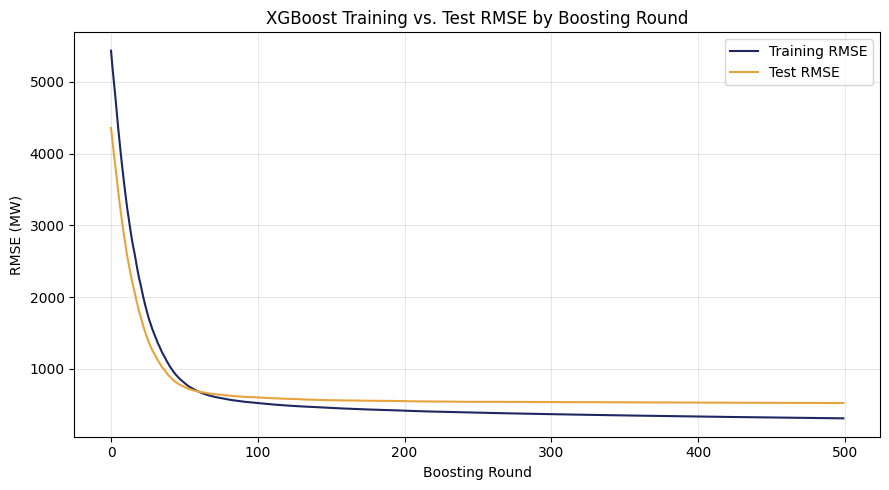

In [22]:
xgb_evals = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(xgb_evals["validation_0"]["rmse"], label="Training RMSE", color="#1e2761")
ax.plot(xgb_evals["validation_1"]["rmse"], label="Test RMSE", color="#e8a33d")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (MW)")
ax.set_title("XGBoost Training vs. Test RMSE by Boosting Round")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
from lightgbm import LGBMRegressor

# X_sub_train / X_val / y_sub_train / y_val reused from the XGBoost tuning cell above
lgbm_param_grid = list(itertools.product([31, 63], [0.05, 0.1], [200, 500]))

best_lgbm_params, best_lgbm_val_rmse = None, float("inf")
for num_leaves, lr, n_est in lgbm_param_grid:
    model = LGBMRegressor(
        num_leaves=num_leaves, learning_rate=lr, n_estimators=n_est,
        colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1,
    )
    model.fit(X_sub_train, y_sub_train)
    val_pred = model.predict(X_val)
    val_rmse, _, val_mape = evaluate(y_val, val_pred)
    print(f"num_leaves={num_leaves}, lr={lr}, n_estimators={n_est}: validation RMSE = {val_rmse:,.1f} MW, MAPE = {val_mape:.2f}%")
    if val_rmse < best_lgbm_val_rmse:
        best_lgbm_val_rmse, best_lgbm_params = val_rmse, (num_leaves, lr, n_est)

print(f"\nSelected LightGBM params (num_leaves, learning_rate, n_estimators): {best_lgbm_params}")

# Refit on the full training set with the selected hyperparameters,
# tracking RMSE per boosting round for the training loss plot
lgbm_model = LGBMRegressor(
    num_leaves=best_lgbm_params[0], learning_rate=best_lgbm_params[1], n_estimators=best_lgbm_params[2],
    colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1,
)
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric="rmse",
)
lgbm_pred = lgbm_model.predict(X_test)

lgbm_rmse, lgbm_mae, lgbm_mape = evaluate(y_test, lgbm_pred)
print("\nLightGBM:")
print(f"  RMSE: {lgbm_rmse:,.1f} MW")
print(f"  MAE:  {lgbm_mae:,.1f} MW")
print(f"  MAPE: {lgbm_mape:.2f}%")

num_leaves=31, lr=0.05, n_estimators=200: validation RMSE = 216.2 MW, MAPE = 0.69%
num_leaves=31, lr=0.05, n_estimators=500: validation RMSE = 204.3 MW, MAPE = 0.64%
num_leaves=31, lr=0.1, n_estimators=200: validation RMSE = 228.1 MW, MAPE = 0.67%
num_leaves=31, lr=0.1, n_estimators=500: validation RMSE = 221.8 MW, MAPE = 0.65%
num_leaves=63, lr=0.05, n_estimators=200: validation RMSE = 231.3 MW, MAPE = 0.71%
num_leaves=63, lr=0.05, n_estimators=500: validation RMSE = 225.8 MW, MAPE = 0.65%
num_leaves=63, lr=0.1, n_estimators=200: validation RMSE = 270.3 MW, MAPE = 0.76%
num_leaves=63, lr=0.1, n_estimators=500: validation RMSE = 263.9 MW, MAPE = 0.74%

Selected LightGBM params (num_leaves, learning_rate, n_estimators): (31, 0.05, 500)

LightGBM:
  RMSE: 507.3 MW
  MAE:  236.6 MW
  MAPE: 0.93%


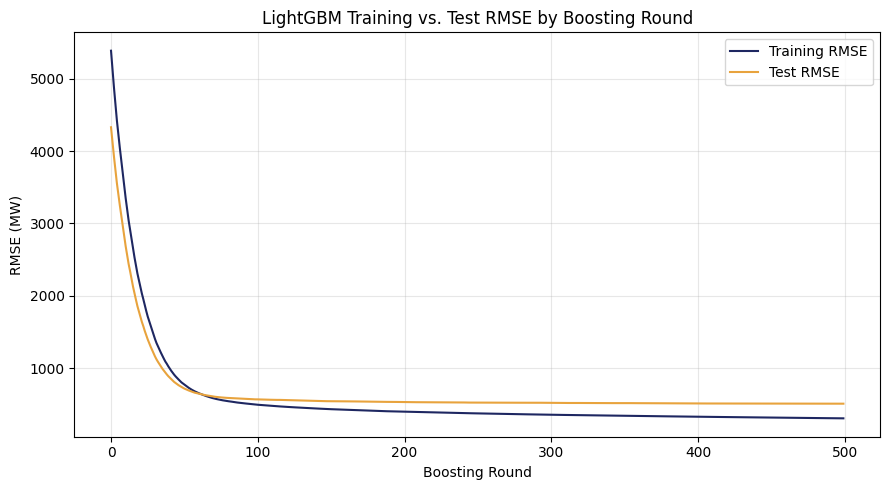

In [24]:
lgbm_evals = lgbm_model.evals_result_

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lgbm_evals["training"]["rmse"], label="Training RMSE", color="#1e2761")
ax.plot(lgbm_evals["valid_1"]["rmse"], label="Test RMSE", color="#e8a33d")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (MW)")
ax.set_title("LightGBM Training vs. Test RMSE by Boosting Round")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance

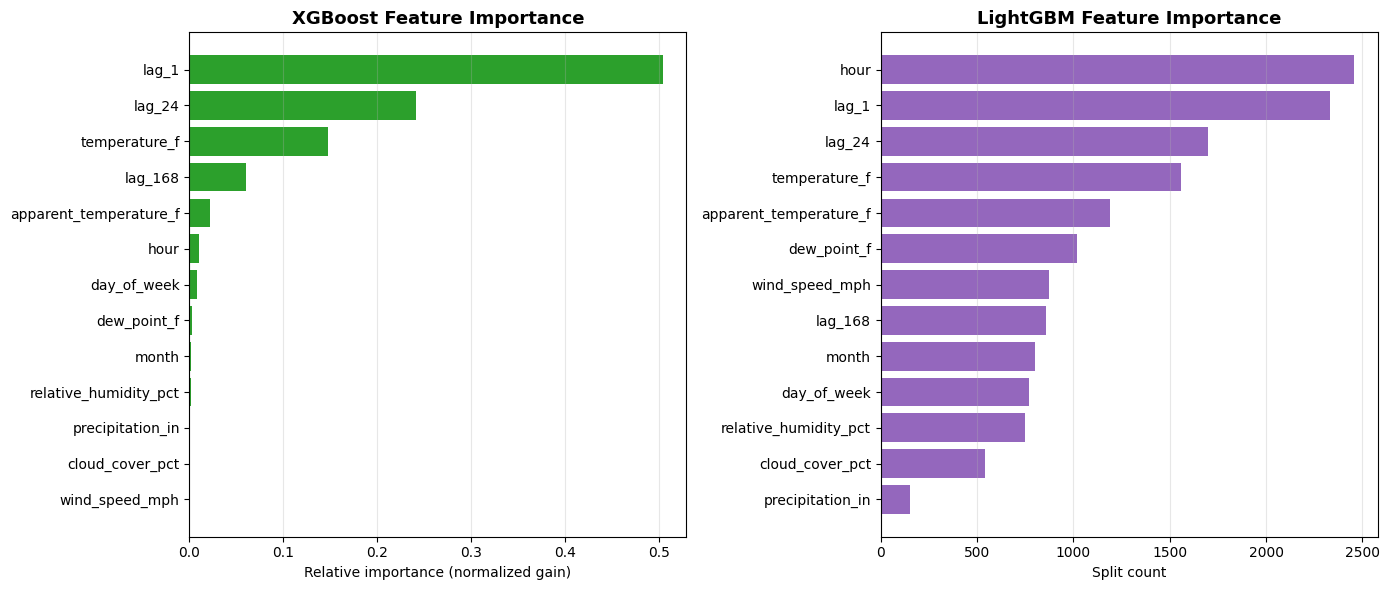

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
axes[0].barh(xgb_importance.index, xgb_importance.values, color="#2ca02c")
axes[0].set_title("XGBoost Feature Importance", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Relative importance (normalized gain)")
axes[0].grid(True, alpha=0.3, axis="x")

lgbm_importance = pd.Series(lgbm_model.feature_importances_, index=feature_cols).sort_values()
axes[1].barh(lgbm_importance.index, lgbm_importance.values, color="#9467bd")
axes[1].set_title("LightGBM Feature Importance", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Split count")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()


In [26]:
print("XGBoost feature importance (gain):")
print(xgb_importance.sort_values(ascending=False))

print("\nLightGBM feature importance (split count):")
print(lgbm_importance.sort_values(ascending=False))

XGBoost feature importance (gain):
lag_1                     0.503748
lag_24                    0.240746
temperature_f             0.147032
lag_168                   0.059665
apparent_temperature_f    0.021740
hour                      0.009745
day_of_week               0.007980
dew_point_f               0.002884
month                     0.001867
relative_humidity_pct     0.001728
precipitation_in          0.001050
cloud_cover_pct           0.000918
wind_speed_mph            0.000897
dtype: float32

LightGBM feature importance (split count):
hour                      2456
lag_1                     2332
lag_24                    1699
temperature_f             1560
apparent_temperature_f    1188
dew_point_f               1017
wind_speed_mph             873
lag_168                    860
month                      802
day_of_week                767
relative_humidity_pct      751
cloud_cover_pct            541
precipitation_in           154
dtype: int32


In [27]:
# Full model comparison (all models evaluated over the same chronological test period)
results = pd.DataFrame(
    {
        "Model": [
            "Naive (lag_1)",
            "Linear Regression",
            f"SARIMA{best_orders[0]}x{best_orders[1]}",
            "Prophet (multi-step)",
            "XGBoost",
            "LightGBM",
        ],
        "RMSE (MW)": [naive_rmse, lr_rmse, arima_rmse, prophet_rmse, xgb_rmse, lgbm_rmse],
        "MAE (MW)": [naive_mae, lr_mae, arima_mae, prophet_mae, xgb_mae, lgbm_mae],
        "MAPE (%)": [naive_mape, lr_mape, arima_mape, prophet_mape, xgb_mape, lgbm_mape],
    }
).round(2)

results


,Model,RMSE (MW),MAE (MW),MAPE (%)
0,Naive (lag_1),1136.68,885.33,3.57
1,Linear Regression,860.19,626.41,2.54
2,"SARIMA(2, 0, 0)x(1, 1, 1, 24)",794.59,274.53,1.13
3,Prophet (multi-step),2530.39,1944.09,7.53
4,XGBoost,524.12,252.47,0.98
5,LightGBM,507.34,236.63,0.93


## Results Visualization

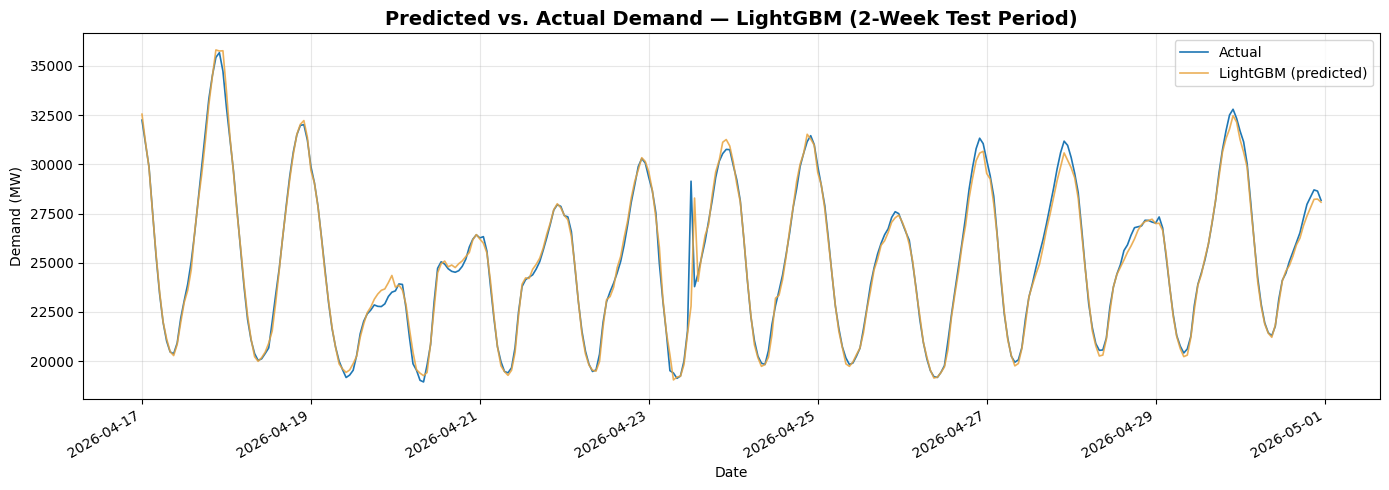

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test["period"], y_test, label="Actual", color="#1f77b4", linewidth=1.2)
ax.plot(test["period"], lgbm_pred, label="LightGBM (predicted)", color="#e8a33d", linewidth=1.2, alpha=0.85)

ax.set_title("Predicted vs. Actual Demand — LightGBM (2-Week Test Period)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Demand (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

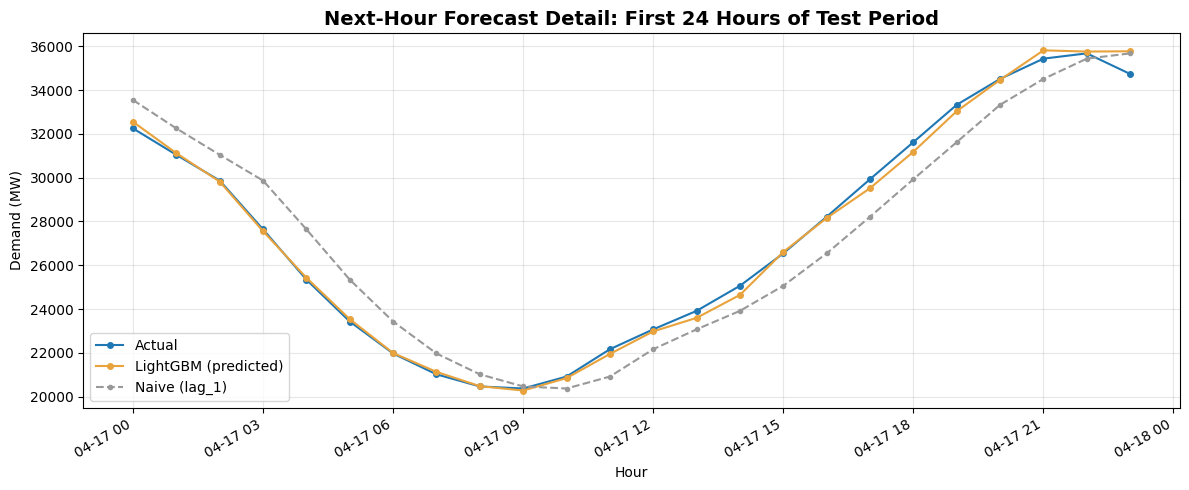

In [29]:
window = 24  # first 24 hours of the test period

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["period"].iloc[:window], y_test.iloc[:window], label="Actual", color="#1f77b4", marker="o", markersize=4)
ax.plot(test["period"].iloc[:window], lgbm_pred[:window], label="LightGBM (predicted)", color="#e8a33d", marker="o", markersize=4)
ax.plot(test["period"].iloc[:window], naive_pred.iloc[:window], label="Naive (lag_1)", color="#999999", linestyle="--", marker="o", markersize=3)

ax.set_title("Next-Hour Forecast Detail: First 24 Hours of Test Period", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour")
ax.set_ylabel("Demand (MW)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

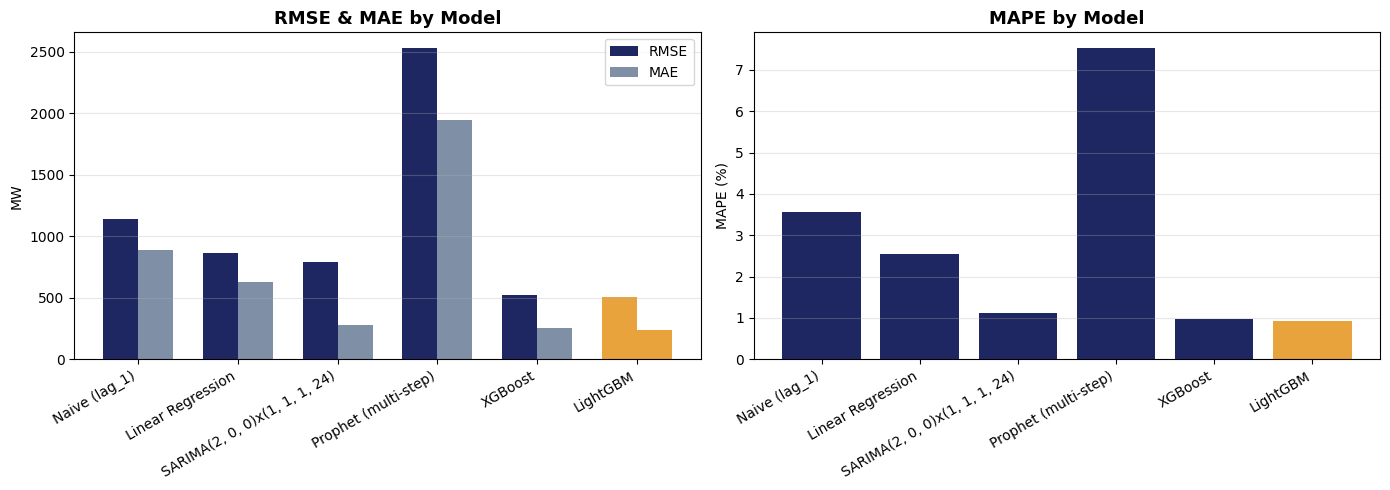

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(results))
width = 0.35
highlight = lambda base: ["#e8a33d" if m == "LightGBM" else base for m in results["Model"]]

axes[0].bar(x - width/2, results["RMSE (MW)"], width, label="RMSE", color=highlight("#1e2761"))
axes[0].bar(x + width/2, results["MAE (MW)"], width, label="MAE", color=highlight("#7f8fa6"))
axes[0].set_xticks(x)
axes[0].set_xticklabels(results["Model"], rotation=30, ha="right")
axes[0].set_title("RMSE & MAE by Model", fontsize=13, fontweight="bold")
axes[0].set_ylabel("MW")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(results["Model"], results["MAPE (%)"], color=highlight("#1e2761"))
axes[1].set_title("MAPE by Model", fontsize=13, fontweight="bold")
axes[1].set_ylabel("MAPE (%)")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### XGBoost & LightGBM — Results

| Model | RMSE (MW) | MAE (MW) | MAPE (%) |
|---|---|---|---|
| SARIMA(2,0,0)x(1,1,1,24) | 794.6 | 274.5 | 1.13 |
| XGBoost | 524.1 | 252.5 | 0.98 |
| LightGBM | 507.3 | 236.6 | 0.93 |

Both gradient-boosted models beat the naive, linear regression, and SARIMA models on every metric. LightGBM edges out XGBoost slightly and ends up with the lowest error of any model using the next-hour setup.

Prophet was tested over the same two weeks, but as mentioned earlier, its numbers aren't really comparable since it had to forecast the whole period at once instead of one hour at a time.

Looking at what each model leaned on most: XGBoost relied heavily on `lag_1` (recent demand), followed by `lag_24` and `temperature_f`, so recent demand history did most of the work. LightGBM's top feature was `hour`, followed by `lag_1`, `lag_24`, and `temperature_f`, so it leaned more on time-of-day patterns alongside recent demand. XGBoost and LightGBM measure importance differently (gain vs. split count), so these rankings are only meaningful within each model, not compared side by side (this is important).

## Conclusion & Limitations

### Summary

Across all six models evaluated over the same held-out two-week test period, **LightGBM had the lowest error metrics** (RMSE 507.3 MW, MAE 236.6 MW, MAPE 0.93%), followed closely by XGBoost (RMSE 524.1 MW, MAE 252.5 MW, MAPE 0.98%). Both gradient-boosted models performed better than the naïve and linear regression baselines and had lower errors than SARIMA under the next-hour forecasting setup. Compared with the naïve forecast, LightGBM reduced RMSE by about 55% and MAPE by 74%.

SARIMA was the best-performing non-tree-based model under the rolling one-step-ahead setup (RMSE 794.6 MW, MAE 274.5 MW, MAPE 1.13%). This aligns with what we already knew based on literature review, which claims SARIMA is used for this kind of problem, recent demand history and the daily demand cycle carry a lot of predictive power as we can see in the results.

Feature importance was used to see which features the gradient-boosted models relied on most. XGBoost importance was measured using gain, while LightGBM importance was measured using split count. Since these methods measure importance differently, that is good for ranking features within each model not necessarily compare directly between the two models.


### Limitations

- Prophet's results may not really be comparable to the other models. Every other model got to look at the actual demand from the hour before when making its next prediction, but Prophet had to guess the whole two-week period in one shot with no updates along the way. That's a much harder task, so it's probably not really fair to say Prophet "did worse" than SARIMA or the tree models, considering it was solving a different problem. 

- We only trained SARIMA on the last 90 days of data instead of the full two years. Fitting a seasonal ARIMA model on the entire training set turned out to be very slow, so we scaled the window down. That means SARIMA had less history to learn from than linear regression, XGBoost, LightGBM, and Prophet.

- Hyperparameters for Prophet, XGBoost, and LightGBM were all picked using just the last week of training data as a validation set (SARIMA used AIC instead). We didn't do proper time-series cross-validation across multiple periods, so it's possible the settings we picked fit that one week a bit too well and wouldn't hold up as well somewhere else.

- Linear regression, Prophet, XGBoost, and LightGBM all use the actual measured weather at the time being predicted, not a forecast. In a real system you wouldn't have that yet, only a weather forecast, which is less accurate. So these four models are probably performing a little better here than they would in an actual deployment. SARIMA doesn't have this issue since it never uses weather at all.

- Our test period is just two weeks, April 17 through 30, 2026. That's generally considered enough to compare the models fairly against each other, but it doesn't tell us how they'd hold up in a different season, especially something like peak summer demand, when usage patterns probably look pretty different.

### Final Model Comparison

| Model | RMSE (MW) | MAE (MW) | MAPE (%) | Evaluation Setup |
|---|---|---|---|---|
| Naive (lag_1) | 1,136.7 | 885.3 | 3.57 | Rolling next-hour |
| Linear Regression | 860.2 | 626.4 | 2.54 | Rolling next-hour using lag features |
| SARIMA(2,0,0)x(1,1,1,24) | 794.6 | 274.5 | 1.13 | Rolling one-step-ahead |
| Prophet (multi-step) | 2,530.4 | 1,944.1 | 7.53 | 2-week multi-step |
| XGBoost | 524.1 | 252.5 | 0.98 | Rolling next-hour using lag features |
| LightGBM | 507.3 | 236.6 | 0.93 | Rolling next-hour using lag features |

### Future Work

Things we can explore: would LightGBM still win if we tested it on a completely different season? Our test period was two spring weeks, and we'd like to know whether the model holds up during a summer heat wave, when demand swings are bigger and probably harder to predict. Running the whole comparison again with walk-forward validation across multiple seasons would give a much more honest answer than our single two-week window.

Another valid question is how much of our models' accuracy is quietly relying on "cheating" with real weather data instead of a forecast. It would be interesting to swap in actual weather forecasts (even a simple one) and see how much the errors grow, that gap would tell us something real about how these models would perform if they were actually deployed.

We only asked the models to predict one hour into the future. We'd like to try pushing that out to 24 or 48 hours and see how much accuracy we lose as the horizon grows, since that's a much more realistic ask for a utility company planning ahead.

Some other smaller ideas could also be interesting to explore: does adding holidays as a feature help at all, given how different demand probably looks on July 4th versus a random Tuesday? And since XGBoost and LightGBM ended up so close in performance, we're curious whether just averaging their two predictions together beats either one alone, or whether they're making similar enough mistakes that it wouldn't help much.